In [86]:
!conda activate Rutgers
!conda env list | findstr Rutgers
# !conda install matplotlib
# !pip install pandas_datareader

Rutgers               *  C:\ProgramData\anaconda3\envs\Rutgers
                         c:\Users\ellio\Rutgers\simulation\.conda


In [87]:
# !pip install --upgrade yfinance
import sys
!{sys.executable} --version

import math
import numpy as np
from datetime import datetime
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display
from math import log
from qpsolvers import solve_qp
from scipy import stats

%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

Python 3.14.2


In [88]:
# https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average

import warnings
warnings.filterwarnings("ignore")

comparies, tickers = ["Dow Jones Index"],['DJI']

tickers_df = yf.download(tickers, start="1986-01-01", end="1988-12-31")
# tickers_df = yf.download(tickers, start="1987-01-01", end="1988-07-31")
# tickers_df = yf.download(tickers, start="1985-01-01", end="1987-07-31")
tickers_df = yf.download(tickers, start="1980-01-01", end="1990-12-31")
companies, tickers = ['S&P500 Index'], ['^GSPC']
tickers_df = yf.download("^GSPC", start="2006-01-01", end="2010-12-31")   # S&P500 index

# from pandas_datareader import data as pdr
# import datetime

# start = datetime.datetime(2006, 1, 1)
# end = datetime.datetime(2010, 12, 31)

# tickers_df = pdr.DataReader("SP500", "fred", start, end)

returns = tickers_df['Close'].map(log).diff()[1:]

returns.columns

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Index(['^GSPC'], dtype='str', name='Ticker')

Jarque–Bera Statistic: 3855.3007
p-value: 0.0
Reject H0: Data are NOT normally distributed.



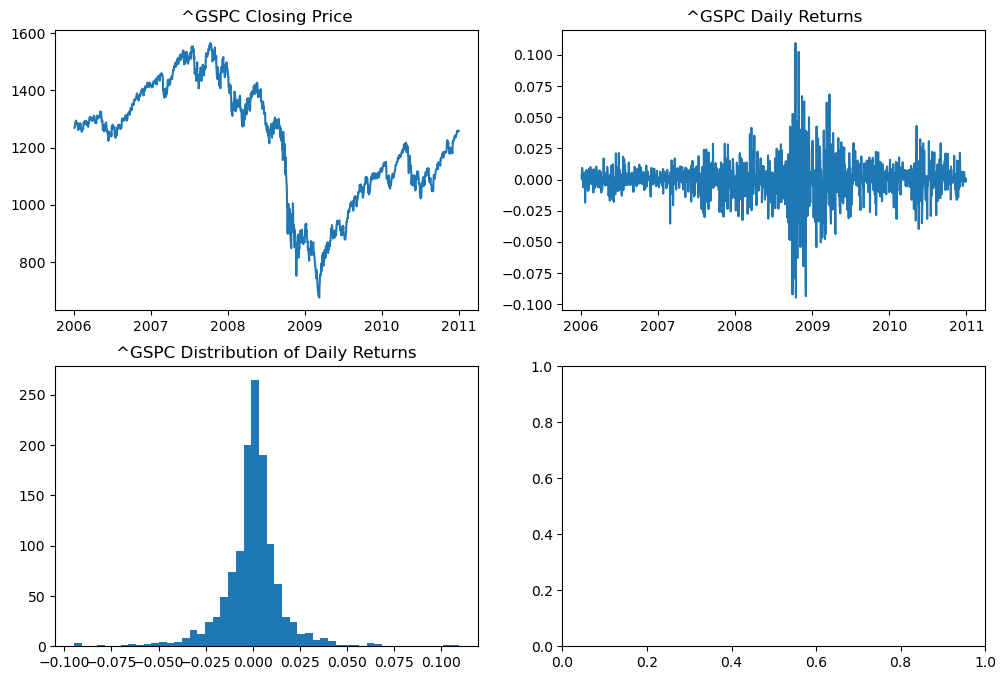

In [89]:
jb_stat, jb_pvalue = stats.jarque_bera(returns)

print("Jarque–Bera Statistic:", round(jb_stat, 4))
print("p-value:", jb_pvalue)

if jb_pvalue < 0.05:
    print("Reject H0: Data are NOT normally distributed.\n")
else:
    print("Fail to reject H0: Data are consistent with normality.\n")
    
fig,axs = plt.subplots(2,2, figsize=(12,8))

axs[0,0].plot(tickers_df['Close'])
axs[0,0].set_title(f"{tickers[0]} Closing Price")
axs[0,1].plot(returns)
axs[0,1].set_title(f"{tickers[0]} Daily Returns")
axs[1,0].hist(returns,50)
axs[1,0].set_title(f"{tickers[0]} Distribution of Daily Returns")
plt.show()

In [90]:
def hill_estimator(data, k):
    """
    Calculates the Hill Estimator for the tail index.
    data: array of investment returns
    k: number of upper order statistics to use
    """
    # Sort data in ascending order
    sorted_data = np.sort(data)
    n = len(data)
    
    # We focus on the largest 'k' values (the tail)
    # For returns, you usually apply this to losses (negative returns)
    tail_data = sorted_data[:k]
    threshold = sorted_data[(k + 1)]    

    # Hill Formula
    hill_est = np.mean(np.log(-tail_data) - np.log(-threshold))
    return hill_est

Hill tail index ξ̂ = 0.3749
Threshold u = 0.032347


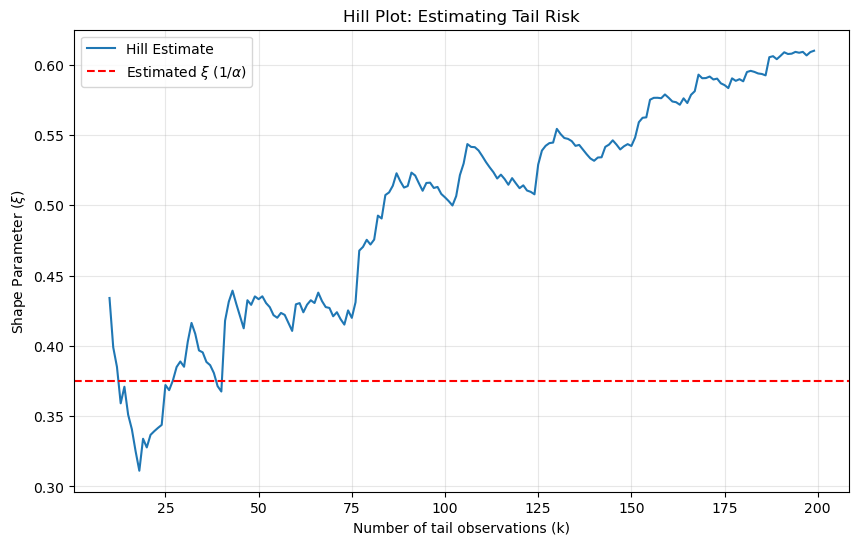

In [91]:
returns1 = np.array(-returns).T[0].tolist()

X = np.sort(np.abs(returns1))
n = len(X)

# =====================================================
# 1. Hill Estimator
# =====================================================
k = int(0.05 * n)      # top 5% tail
u = X[-k-1]            # threshold
tail = X[-k:]

xi_hill = (1/k) * np.sum(np.log(tail) - np.log(u))

print("Hill tail index ξ̂ =", round(xi_hill, 4))
print("Threshold u =", round(u, 6))

# Pareto density implied by Hill
def pareto_density(x, xi, u):
    return (1 / (xi * u)) * (x / u) ** (-1/xi - 1)

x_vals = np.linspace(u, max(X), 500)
y_pareto = pareto_density(x_vals, xi_hill, u)

# plt.hist(data, 30)

# Calculate Hill estimates for various k values
ks = range(10, min(200, len(returns1)-1))
estimates = [hill_estimator(returns1, k) for k in ks]
# print(estimates)

# Plotting the Hill Plot
plt.figure(figsize=(10, 6))
plt.plot(ks, estimates, label='Hill Estimate')
# plt.axhline(y=1/true_alpha, color='r', linestyle='--', label='True $\\xi$ (1/$\\alpha$)')
plt.axhline(y=xi_hill, color='r', linestyle='--', label='Estimated $\\xi$ (1/$\\alpha$)')
plt.xlabel('Number of tail observations (k)')
plt.ylabel('Shape Parameter ($\\xi$)')
plt.title('Hill Plot: Estimating Tail Risk')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [92]:
# =====================================================
# 2. POT–GPD MLE Fit
# =====================================================
exceedances = tail - u
xi_mle, loc_mle, beta_mle = stats.genpareto.fit(exceedances)

print("GPD MLE tail index ξ̂ =", round(xi_mle, 4))
print("GPD scale β̂ =", round(beta_mle, 6))

def gpd_density(x, xi, beta, u):
    y = x - u
    return (1/beta) * (1 + xi*y/beta) ** (-1/xi - 1)

y_gpd = gpd_density(x_vals, xi_mle, beta_mle, u)

POT_title = f"{beta_mle = :0.4f}, {xi_mle = :0.4f}"

# print(POT_title)
# =====================================================
# 3. EVT-based VaR and ES (99%)
# =====================================================
p = 0.99
Nu = k

VaR_evt = u + (beta_mle/xi_mle) * (((n/Nu)*(1-p))**(-xi_mle) - 1)
ES_evt = VaR_evt/(1 - xi_mle) + (beta_mle - xi_mle*u)/(1 - xi_mle)


print("\nEVT VaR(99%) =", round(VaR_evt, 6))
print("EVT ES(99%) =", round(ES_evt, 6))

GPD MLE tail index ξ̂ = 1.4178
GPD scale β̂ = 0.008748

EVT VaR(99%) = 0.085454
EVT ES(99%) = -0.115707


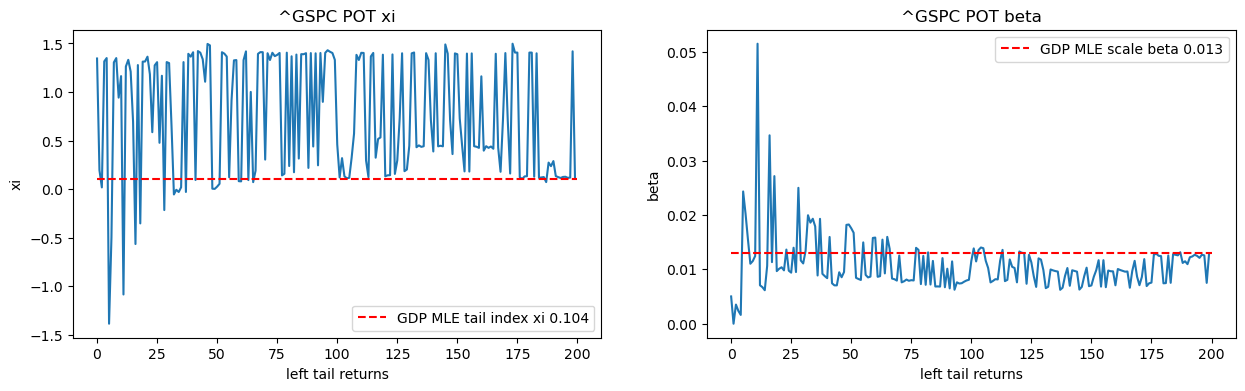

In [93]:
npts = 200
xi, beta = [],[]
for k1 in range(npts):
    u1 = X[-k1-1]            # threshold
    tail1 = X[-k1:]
    
    exceedances = tail1 - u1
    xi_mle, loc_mle, beta_mle = stats.genpareto.fit(exceedances)
    xi.append(xi_mle)
    beta.append(beta_mle)

fig,axs = plt.subplots(1,2,figsize=(15,4))
axs[0].plot(xi)
axs[0].plot([0,npts],[xi_mle] * 2, '--', c='red', label=f"GDP MLE tail index xi {xi_mle:0.3f}")
axs[0].set_title(f"{tickers[0]} POT xi")
axs[0].set_xlabel(f"left tail returns")                 
axs[0].set_ylabel(f"xi")                 
axs[0].legend()
axs[1].plot(beta)
axs[1].plot([0,npts],[beta_mle] * 2, '--', c='red', label=f"GDP MLE scale beta {beta_mle:0.3f}")
axs[1].set_title(f"{tickers[0]} POT beta")
axs[1].set_xlabel(f"left tail returns")                 
axs[1].set_ylabel(f"beta")   
axs[1].legend()
plt.show()

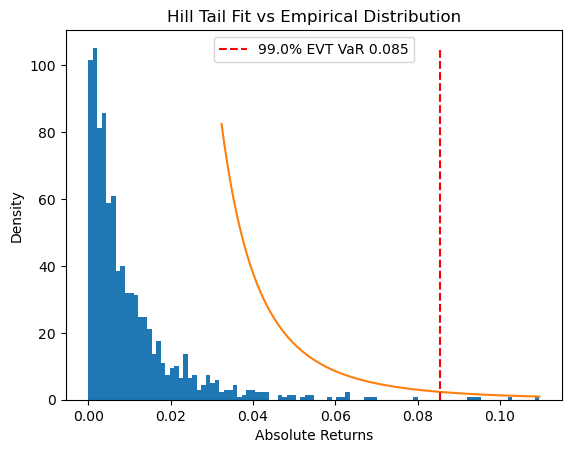

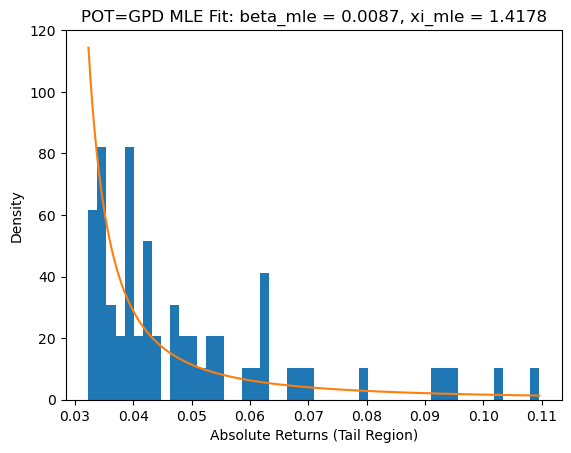

In [94]:
# =====================================================
# 4A. Plot Hill Tail Fit vs Empirical Distribution
# =====================================================
plt.figure()
counts, bin_edges, patches = plt.hist(X, bins=100, density=True)
plt.plot(x_vals, y_pareto)
plt.plot([VaR_evt] * 2, [min(counts), max(counts)],'--', c='red', label=f"{100 * p}% EVT VaR {VaR_evt:0.3f}")

plt.title("Hill Tail Fit vs Empirical Distribution")
plt.xlabel("Absolute Returns")
plt.ylabel("Density")
plt.legend()
plt.show()

# =====================================================
# 4B. Plot GPD MLE Fit vs Empirical Tail
# =====================================================
plt.figure()
counts, bin_edges, patches = plt.hist(X[X >= u], bins=50, density=True)
plt.plot(x_vals, y_gpd)

plt.title(f"POT=GPD MLE Fit: {POT_title}")
plt.xlabel("Absolute Returns (Tail Region)")
plt.ylabel("Density")
plt.show()

In [95]:
max(counts), bin_edges, patches

(np.float64(82.21734731272485),
 array([0.03234731, 0.0338918 , 0.0354363 , 0.03698079, 0.03852528,
        0.04006978, 0.04161427, 0.04315876, 0.04470326, 0.04624775,
        0.04779224, 0.04933674, 0.05088123, 0.05242572, 0.05397022,
        0.05551471, 0.0570592 , 0.05860369, 0.06014819, 0.06169268,
        0.06323717, 0.06478167, 0.06632616, 0.06787065, 0.06941515,
        0.07095964, 0.07250413, 0.07404863, 0.07559312, 0.07713761,
        0.07868211, 0.0802266 , 0.08177109, 0.08331558, 0.08486008,
        0.08640457, 0.08794906, 0.08949356, 0.09103805, 0.09258254,
        0.09412704, 0.09567153, 0.09721602, 0.09876052, 0.10030501,
        0.1018495 , 0.103394  , 0.10493849, 0.10648298, 0.10802747,
        0.10957197]),
 <BarContainer object of 50 artists>)

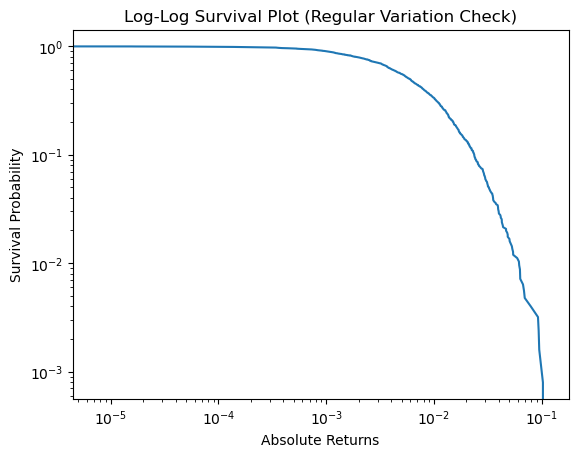

In [96]:
# =====================================================
# 4C. Log-Log Survival Plot (Tail Diagnostic)
# =====================================================
plt.figure()

# Empirical survival function
survival = 1 - np.arange(1, n+1)/n
plt.loglog(X, survival)

plt.title("Log-Log Survival Plot (Regular Variation Check)")
plt.xlabel("Absolute Returns")
plt.ylabel("Survival Probability")
plt.show()